In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_from_disk
import numpy as np
from collections import Counter

In [20]:
dataset = load_from_disk('dataset')

In [21]:
# applying EDA only on training dataset  

In [22]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})


In [23]:
# as using dataset from hugging faces its easy to access and read

In [24]:
dataset["train"]

Dataset({
    features: ['image', 'label'],
    num_rows: 4096
})

In [29]:
train = dataset["train"]

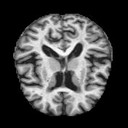

In [30]:
# d contains all the dataset for train data with images and it's label
# d[0] -> first data ["image"] displaying image as its describe above each data members in dataset is array of ['image' and 'label']
train[0]["image"]

In [33]:
training_labels = train["label"]

In [34]:
len(training_labels)

4096

In [35]:
training_labels_cnt = Counter(training_labels)

In [36]:
training_labels_cnt

Counter({2: 2044, 3: 1430, 0: 579, 1: 43})

In [37]:
class_names = train.features["label"].names

In [38]:
class_names

['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']

In [43]:
for label,count in training_labels_cnt.items():
    print(f"{class_names[label]} - {count}")
    

Very_Mild_Demented - 1430
Non_Demented - 2044
Mild_Demented - 579
Moderate_Demented - 43


In [44]:
# plotting information using matlibplot

In [47]:
clss_name = [class_names[i] for i in training_labels_cnt]

In [48]:
clss_name

['Very_Mild_Demented', 'Non_Demented', 'Mild_Demented', 'Moderate_Demented']

In [49]:
cnt = [training_labels_cnt[c] for c in training_labels_cnt]

In [50]:
cnt

[1430, 2044, 579, 43]

In [51]:
# so clss_name contains the names of target(t) or dependent variable and cnt contains count of each

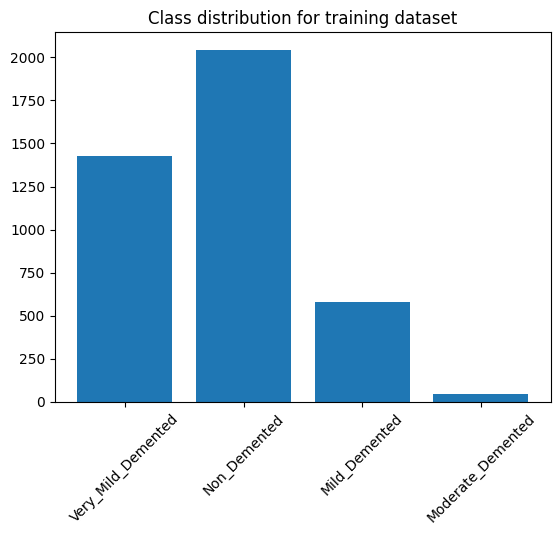

In [57]:
plt.bar(clss_name,cnt)
plt.xticks(rotation=45)
plt.title("Class distribution for training dataset")
plt.show()

In [59]:
# this shows that we have very few data for moderate_demented and high dataset for Non_demented. This shows that there is highly imbalance
# dataset

In [129]:
# 2nd EDA - Mean and Variance Image
# Here we pick global mean and variance rather than classwise to see dataset quality and alignment of image are brain MRI is aligned in same
# axis left right center

In [63]:
# extracting all the images from dataset

In [92]:
# checking if images are already grayscale and dimension of image is 128x128
# sampling
i = train[2]["image"]
print(i.size,i.mode)
i = train[len(train)-1]["image"]
print(i.size,i.mode)

(128, 128) L
(128, 128) L


In [78]:
# as the dimension of image is already 128,128 and L means Luminance (single channel with 8 bit grayscale image (0-255)
# note if there it was RGB it will return RGB which is 3X8-bit color

In [94]:
images = [] #storing all images here
for x in train:
    images.append(x["image"])
len(images)

4096

In [98]:
# normalizing images first converting images into numpy array and diving it 255 as our value for color ranges from 0-255
X = np.array(images,dtype=np.float32)/255.0

In [112]:
mean_img = np.mean(X,axis=0)

In [113]:
mean_img 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(128, 128), dtype=float32)

In [119]:
variance_img = np.var(X, axis=0)

In [120]:
variance_img 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(128, 128), dtype=float32)

In [116]:
# showing the mean value

In [125]:
plt.figure(figsize=(2,5))

<Figure size 200x500 with 0 Axes>

<Figure size 200x500 with 0 Axes>

Text(0.5, 1.0, 'Mean of all Image')

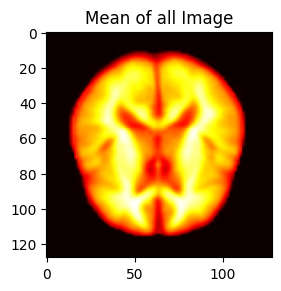

In [130]:
plt.subplot(1,2,1)
plt.imshow(mean_img,cmap="hot")
plt.title("Mean of all Image")

Text(0.5, 1.0, 'Variance of all Image')

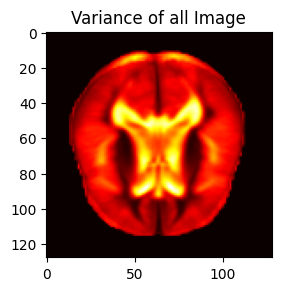

In [134]:
plt.subplot(1,2,1)
plt.imshow(variance_img,cmap="hot")
plt.title("Variance of all Image")

In [133]:
# high variance data contains more information than low variance data, here in image the background value don't change so it is back.